In [9]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.Plotter.index import Plotter
from Network.index import ModelNetwork
from utils.index import *

In [10]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu118
True
Quadro P6000


# HISTÓRICO DE TREINAMENTO

In [11]:
df = []

for bakup in os.listdir('Backup/'):
    path = f'Backup/{bakup}/info.json'

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())
    
    info = dict()

    for key, value in file.items():
        info.update(value)

    if info.get('marlim_iou') is not None and file['marlim_iou'].get('mean') is not None:
        info['marlim_iou'] = file['marlim_iou']['mean']

    if not info.get('dataset'):
        info['dataset'] = 'facies'

    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df.head()

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,network,dataset,img_size,step,multiclass,lr,dropout,num_filters,n_images,classes,channels,deep_supervision,0,1,2,3,4,5,id,mean,gpus,multi-gpu
3,model_1,dice_focal,plateau,200,4,0.807174,0.839474,resaceunet,facies,"[4, 256, 256]",10,True,0.0005,0.05,32,"{'total': 2133, 'train': 1705, 'val': 214, 'te...",6,1,False,0.962114,0.779671,0.827442,0.867539,0.836034,0.985383,1,0.876364,NaN,NaN
1,model_2,dice_focal,plateau,200,4,0.883308,0.889786,resaceunet,facies,"[4, 256, 256]",5,True,0.0005,0.05,32,"{'total': 4239, 'train': 3391, 'val': 424, 'te...",6,1,False,0.982052,0.880043,0.909889,0.934262,0.911499,0.991673,2,0.934903,NaN,NaN
6,model_2,dice_focal,plateau,200,4,0.936462,0.932135,resaceunet,facies,"[4, 256, 256]",3,True,0.0005,0.05,32,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.989032,0.922202,0.942306,0.955270,0.937645,0.993483,2,0.956657,NaN,NaN
15,model_3,dice_focal,plateau,200,4,0.934216,0.929998,resaceunet,facies,"[4, 256, 256]",3,True,0.0005,0.05,32,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.988174,0.917811,0.939541,0.953049,0.934021,0.993189,3,0.954298,NaN,NaN
9,model_4,dice_focal,plateau,200,4,0.936984,0.935020,unet3d_v2,facies,"[4, 256, 256]",3,True,0.0005,0.05,32,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.989553,0.924252,0.944115,0.956323,0.940972,0.993895,4,0.958185,NaN,NaN


### Filtrando o Alvo

In [12]:
df['total_images'] = [n_images.get('total') for n_images in df.n_images.values]
df.head(2)

,path,loss,scheduler,epochs,batch_size,val_iou,test_iou,network,dataset,img_size,step,multiclass,lr,dropout,num_filters,n_images,classes,channels,deep_supervision,0,1,2,3,4,5,id,mean,gpus,multi-gpu,total_images
3,model_1,dice_focal,plateau,200,4,0.807174,0.839474,resaceunet,facies,"[4, 256, 256]",10,True,0.0005,0.05,32,"{'total': 2133, 'train': 1705, 'val': 214, 'te...",6,1,False,0.962114,0.779671,0.827442,0.867539,0.836034,0.985383,1,0.876364,NaN,NaN,2133
1,model_2,dice_focal,plateau,200,4,0.883308,0.889786,resaceunet,facies,"[4, 256, 256]",5,True,0.0005,0.05,32,"{'total': 4239, 'train': 3391, 'val': 424, 'te...",6,1,False,0.982052,0.880043,0.909889,0.934262,0.911499,0.991673,2,0.934903,NaN,NaN,4239


# ANÁLISE DE VARIAÇÕES

target: step | fixed: {'network': 'resaceunet', 'img_size': '[4, 256, 256]', 'batch_size': 4}


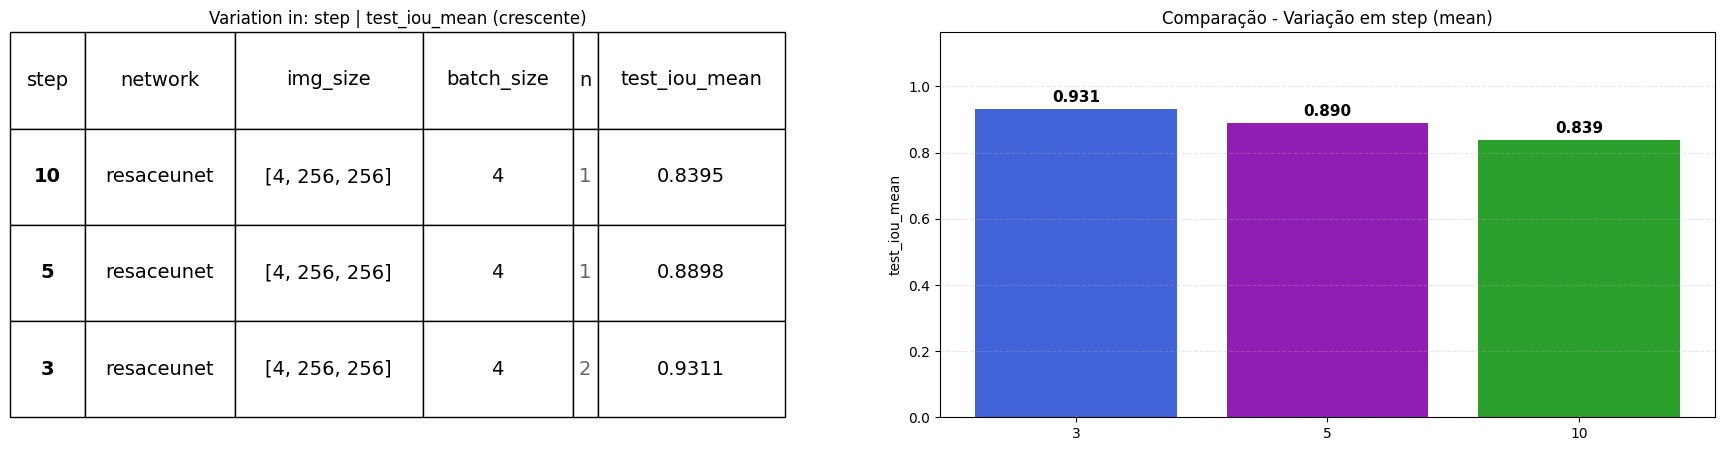

target: network | fixed: {'step': 3, 'img_size': '[4, 256, 256]', 'batch_size': 4}


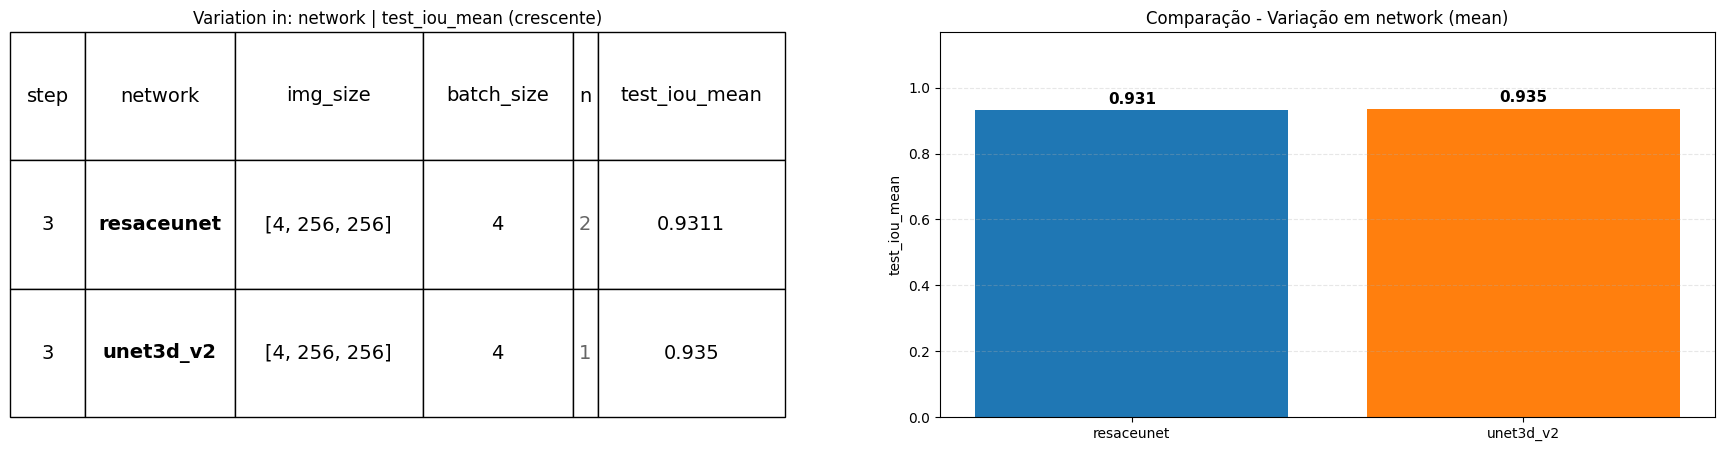

target: img_size | fixed: {'step': 3, 'network': 'resaceunet', 'batch_size': 2}


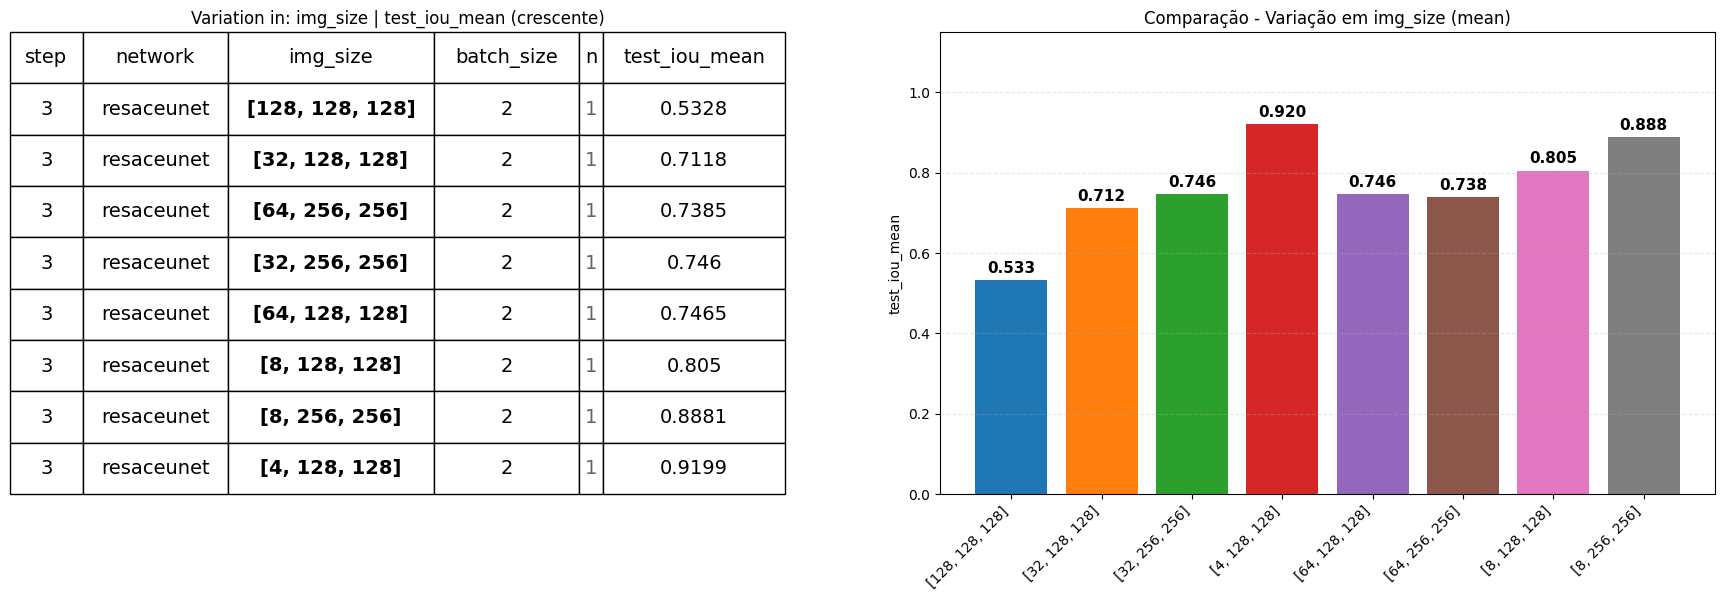

target: img_size | fixed: {'step': 3, 'network': 'resaceunet', 'batch_size': 4}


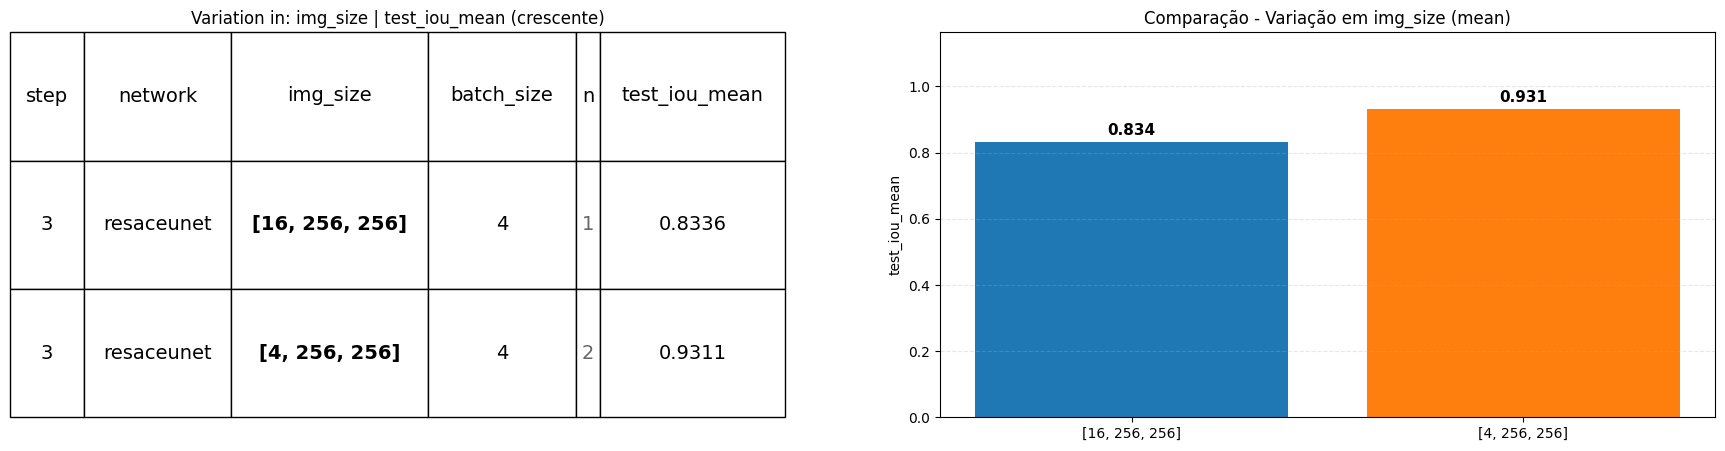

target: batch_size | fixed: {'step': 3, 'network': 'resaceunet', 'img_size': '[4, 256, 256]'}


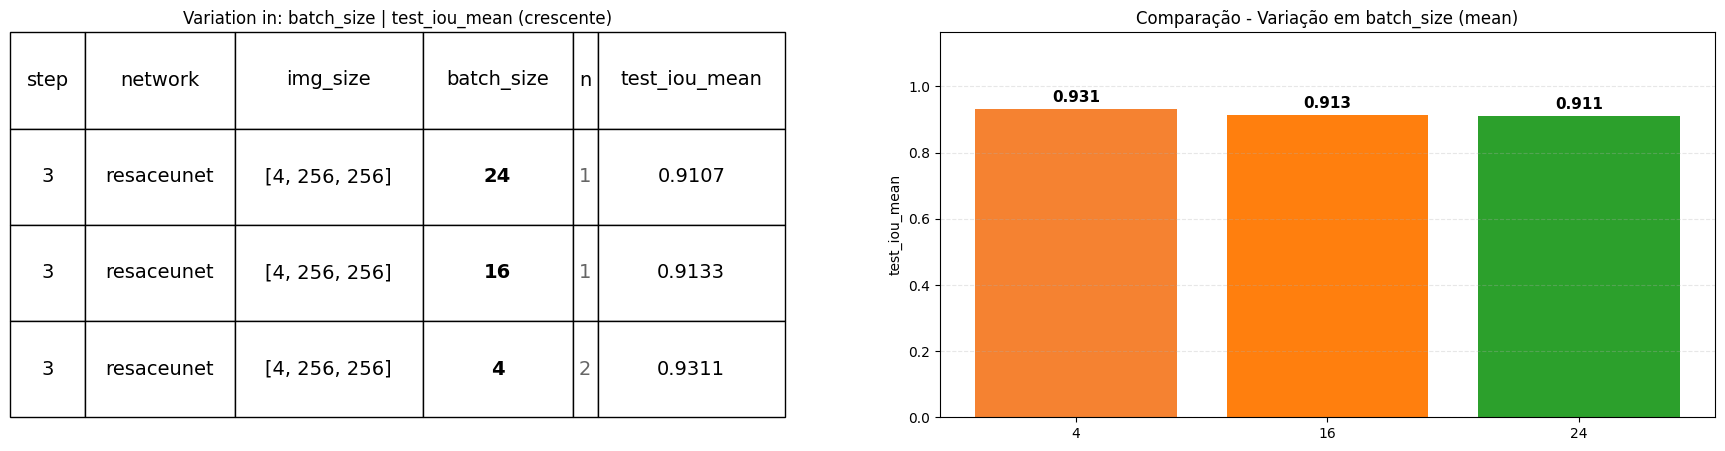

In [13]:
import os

import matplotlib.pyplot as plt
import pandas as pd


class VariationAnalysis:
    MODES = ('min', 'max', 'mean', 'std')
    COUNT = 'n'

    def __init__(self, df, variations, id=None, metric='test_mre_mm',
                 mode='min', asc=True, max_str_len=25):
        if mode not in self.MODES:
            raise ValueError(f'mode must be one of {self.MODES}')

        self.df = df.copy()
        self.variations = [v for v in variations if v in self.df.columns]
        self.id = id if id in self.df.columns else None
        self.metric = metric
        self.mode = mode
        self.asc = asc
        self.max_str_len = max_str_len
        self.metric_label = f'{metric}_{mode}'
        self._prepare()

    def _prepare(self):
        self.df[self.metric] = pd.to_numeric(self.df[self.metric], errors='coerce')
        self.df = self.df.dropna(subset=[self.metric]).reset_index(drop=True)

        for col in self.variations:
            numeric = pd.to_numeric(self.df[col], errors='coerce')
            is_numeric = numeric.notna().sum() == self.df[col].notna().sum()
            self.df[col] = numeric if is_numeric else self.df[col].astype(str)

        if self.id:
            self.df[self.id] = self.df[self.id].astype(str)

    def _slices(self):
        for var in self.variations:
            fixed = [c for c in self.variations if c != var]
            groups = self.df.groupby(fixed, dropna=False) if fixed else [(None, self.df)]

            for _, group in groups:
                if group[var].nunique(dropna=False) <= 1:
                    continue
                fixed_values = group.iloc[0][fixed].to_dict() if fixed else {}
                yield var, fixed_values, group

    def _aggregate(self, group, keys):
        gb = group.groupby(keys, dropna=False)[self.metric]
        agg = (gb.agg([self.mode, 'size'])
                 .rename(columns={self.mode: self.metric_label, 'size': self.COUNT})
                 .reset_index())

        if self.id and self.mode in ('min', 'max'):
            idx = gb.idxmin() if self.mode == 'min' else gb.idxmax()
            agg[self.id] = group.loc[idx.values, self.id].values

        return agg[agg[self.metric_label].notna()]

    def _build_table(self, agg, fixed_values):
        table = agg.sort_values(self.metric_label, ascending=self.asc, kind='stable').copy()
        table[self.metric_label] = table[self.metric_label].round(4)

        for col, value in fixed_values.items():
            table[col] = value

        cols = [c for c in self.variations if c in table.columns]
        if self.id in table.columns:
            cols.append(self.id)
        return table[cols + [self.COUNT, self.metric_label]]

    def _varying(self, table):
        return [c for c in self.variations
                if c in table.columns and table[c].nunique(dropna=False) > 1]

    def _labels(self, table):
        cols = self._varying(table) or [c for c in self.variations if c in table.columns]
        if not cols:
            return [str(i + 1) for i in range(len(table))]
        return [' | '.join(str(v)[:self.max_str_len] for v in row)
                for row in table[cols].values]

    def _format(self, table):
        show = table.astype(str)
        if self.id in show.columns:
            show[self.id] = show[self.id].map(os.path.basename)

        for col in show.columns:
            if col != self.COUNT:
                show[col] = show[col].str.slice(0, self.max_str_len)
        return show

    def _char_widths(self, show):
        widths = []
        for col in show.columns:
            content = int(show[col].str.len().max())
            padding = 1 if col == self.COUNT else 2
            widths.append(max(len(str(col)), content) + padding)
        return widths

    def _fontsize(self, ax, char_widths, rows):
        fig_w, fig_h = ax.figure.get_size_inches()
        pos = ax.get_position()
        fit_w = fig_w * pos.width * 72 / (sum(char_widths) * 0.62)
        fit_h = fig_h * pos.height * 72 / (rows + 1) * 0.55
        return max(6, min(14, fit_w, fit_h))

    def _style(self, tbl, show, bold):
        highlight = {show.columns.get_loc(c): dict(fontweight='bold')
                     for c in bold if c in show.columns}
        if self.COUNT in show.columns:
            highlight[show.columns.get_loc(self.COUNT)] = dict(color='0.4')

        for (row, col), cell in tbl.get_celld().items():
            if row > 0 and col in highlight:
                cell.set_text_props(**highlight[col])

    def _draw_table(self, ax, table, title, bold=()):
        ax.axis('off')
        show = self._format(table)
        char_widths = self._char_widths(show)
        total = sum(char_widths)

        tbl = ax.table(cellText=show.values, colLabels=show.columns,
                       colWidths=[w / total for w in char_widths],
                       loc='center', cellLoc='center', bbox=[0, 0, 1, 1])
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(self._fontsize(ax, char_widths, len(show)))

        self._style(tbl, show, bold)
        ax.set_title(title)

    def _draw_chart(self, values, title):
        vmin, vmax = min(values.values()), max(values.values())
        top = vmax * 1.25 if vmax > 0 else vmax + abs(vmax) * 0.25 + 1e-6
        bottom = min(0.0, vmin * 1.25)

        try:
            Plotter(values, limits=(bottom, top), title=title)
        except NameError:
            bars = plt.bar(list(values.keys()), list(values.values()))
            plt.bar_label(bars, fmt='%.3f')
            plt.ylim(bottom, top)
            plt.xticks(rotation=30)
            plt.title(title)
        plt.ylabel(self.metric_label)

    def _figure(self, table, values, table_title, chart_title, bold=()):
        height = max(5, min(20, len(table) * 0.5 + 2))
        fig = plt.figure(figsize=(22, height))

        ax = fig.add_subplot(1, 2, 1)
        self._draw_table(ax, table, table_title, bold)

        fig.add_subplot(1, 2, 2)
        self._draw_chart(values, chart_title)
        plt.show()

    def _plot_variation(self, var, fixed_values, group, order):
        agg = self._aggregate(group, var)
        if agg.empty:
            return False

        table = self._build_table(agg, fixed_values)
        chart = agg.sort_values(var, kind='stable')
        values = dict(zip(chart[var].astype(str), chart[self.metric_label]))

        self._figure(table, values,
                     f'Variation in: {var} | {self.metric_label} ({order})',
                     f'Comparação - Variação em {var} ({self.mode})',
                     bold=[var])
        return True

    def _plot_remaining(self, covered, order):
        rest = self.df.loc[~self.df.index.isin(covered)]
        if rest.empty or not self.variations:
            return

        agg = self._aggregate(rest, self.variations)
        if agg.empty:
            return

        table = self._build_table(agg, {})
        varying = self._varying(table)
        print(f'target: restantes ({len(table)}) | livres: {varying}')

        values = dict(zip(self._labels(table), table[self.metric_label]))
        self._figure(table, values,
                     f'Sem comparação | {self.metric_label} ({order})',
                     f'Configurações restantes ({self.mode})',
                     bold=varying)

    def plot(self):
        order = 'crescente' if self.asc else 'decrescente'
        covered = set()

        for var, fixed_values, group in self._slices():
            print(f'target: {var} | fixed: {fixed_values}')
            if self._plot_variation(var, fixed_values, group, order):
                covered.update(group.index)

        self._plot_remaining(covered, order)


variations = ['step', 'network', 'img_size', 'batch_size']
analysis = VariationAnalysis(df, variations, id='path', metric='test_iou', mode='mean', asc=True)
analysis.plot()